# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [16]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [17]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
# print(df.shape)
# print(df.info())
# print("Missing values trong các cột:")
# print(df.isnull().sum().T)
print("Tỷ lệ missing của các cột:")
print(df.isnull().mean().sort_values(ascending=False))
...

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ["alive", "who", "adult_male", "class", "deck", "embark_town", "alone", ""]      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
# df = df.drop(columns=...)
df = df.drop(columns=[c for c in leaky if c in df.columns])
print("Các cột còn lại:", list(df.columns))

Tỷ lệ missing của các cột:
deck           0.772166
age            0.198653
embarked       0.002245
embark_town    0.002245
sex            0.000000
pclass         0.000000
survived       0.000000
fare           0.000000
parch          0.000000
sibsp          0.000000
class          0.000000
adult_male     0.000000
who            0.000000
alive          0.000000
alone          0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Mục tiêu của mô hình là dự đoán tỉ lệ sống sót của một nếu họ ở trên tàu Titanic. Trong bài toán này, mô hình cần học mối quan hệ, quy luật của các dữ liệu về `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked` đối với `survived`. Nếu ta truyền vào cả `alive`, dữ liệu này hoàn toàn trùng khớp với `survived`. Vì thế ta để sót lại `alive` tức ta đã làm rò rĩ nhãn (data leakage), trong vấn đề này mô hình gần như đã biết trước đáp án (`alive` == `survived`) vì thế độ chính xác khi ta so sánh với tập train chắc chắn bằng 100% và mô hình gần như không học được gì. Vì thế khi kiếm tra trên tập test, mô hình sẽ thất bại.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [18]:
# TODO 2: shape, info, describe
print("Shape:", df.shape)
df.info()
print(df.describe(include="all"))
...

Shape: (891, 8)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 60.9 KB
          survived      pclass   sex         age       sibsp       parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2         NaN         NaN         NaN   
top            NaN         NaN  male         NaN         NaN         NaN   
freq           NaN         NaN   577         NaN         NaN         NaN   
mean      0.383838    2.308642   NaN   29.699118    0.523008  

Ellipsis

**Trả lời 2 (biến số vs biến phân loại):**

Các biến số bao gồm: `age`, `sibsp`, `parch`, `fare`

Các biến phân loại bao gồm: `pclass`, `sex`, `embarked`, `survived`

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [19]:
# Chỉ thống kê missing ở đây; imputer sẽ được fit trên train trong Task 7.
missing = pd.DataFrame({"Số giá trị thiếu": df.isna().sum(), "Tỷ lệ thiếu (%)": df.isna().mean() * 100})
missing = missing.loc[missing["Số giá trị thiếu"] > 0].sort_values("Tỷ lệ thiếu (%)", ascending=False).round(2)
display(missing)

,Số giá trị thiếu,Tỷ lệ thiếu (%)
age,177,19.87
embarked,2,0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**
```
|    Cột   | % thiếu | Cách xử lý đề xuất |    Lý do     |
|`embarked`|  0.22%  |    Điền `mode`     |Biến phân loại|
|   `age`  | 19.87%  |   Điền `median`    |    Biến số   |
```

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [20]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
from scipy import stats
def dem_outlier_iqr(s):
    q1, q3 = np.percentile(s.dropna(), [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = ((s < lower_bound) | (s > upper_bound)).sum()
    return int(outliers)

def dem_outlier_zscore(s, nguong=3.0):
    outliers = (np.abs(stats.zscore(s.dropna())) > nguong).sum()
    return int(outliers)

# for col in ["age", "fare"]:
for col in ["age", "fare"]:
    iqr_count = dem_outlier_iqr(df[col])
    zscore_count = dem_outlier_zscore(df[col])
    print(f"{col}: Outliers theo IQR = {iqr_count}, Outliers theo Z-score = {zscore_count}")

age: Outliers theo IQR = 11, Outliers theo Z-score = 2
fare: Outliers theo IQR = 116, Outliers theo Z-score = 20


**Trả lời 4 (quyết định với outlier của `fare`):**

Quyết định là giữ lại outlier của `fare`. Trên bộ seaborn, IQR phát hiện 116 điểm còn Z-score phát hiện 20 điểm cộng thêm biểu đồ phhan6 phối của `fare` ở 5.1, cho thấy phân phối lệch phải dài. Vé cao có thể là vé hạng nhất hoặc nhiều chỗ, là thông tin thực tế chứ chưa có bằng chứng là lỗi.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

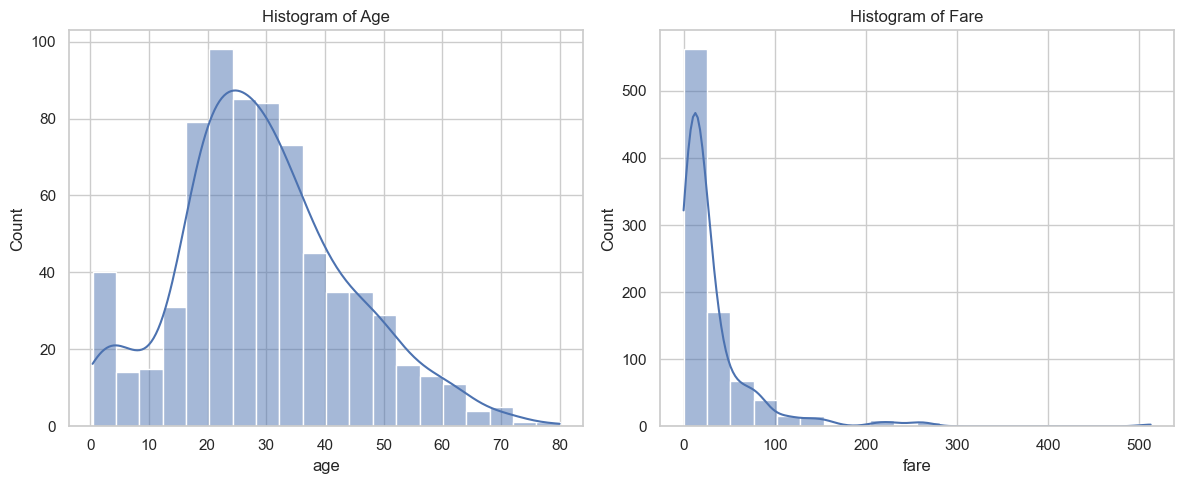

Ellipsis

In [21]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["age"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Histogram of Age")
sns.histplot(df["fare"], bins=20, kde=True, ax=axes[1])
axes[1].set_title("Histogram of Fare")
plt.tight_layout()
plt.show()
...

## Nhận xét

Phân phối của `Age` lệch phải nhẹ, phần lớn du khách tập trung quanh mức 30 tuổi. Tuy nhiên vẫn có rất nhiều du khách lớn tuổi trải dài lên đến 80 tuổi.

Phân phối của `fare` lệch phải rõ rệch, đa số du khách có giá vé thấp (0 - 30). Dù vậy vẫn có người sở hữu tấm vé giá trị rất cao (100, 200, thậm chí hơn 500), đây là phân phối rất điển hình của dữ liệu giá tiền.

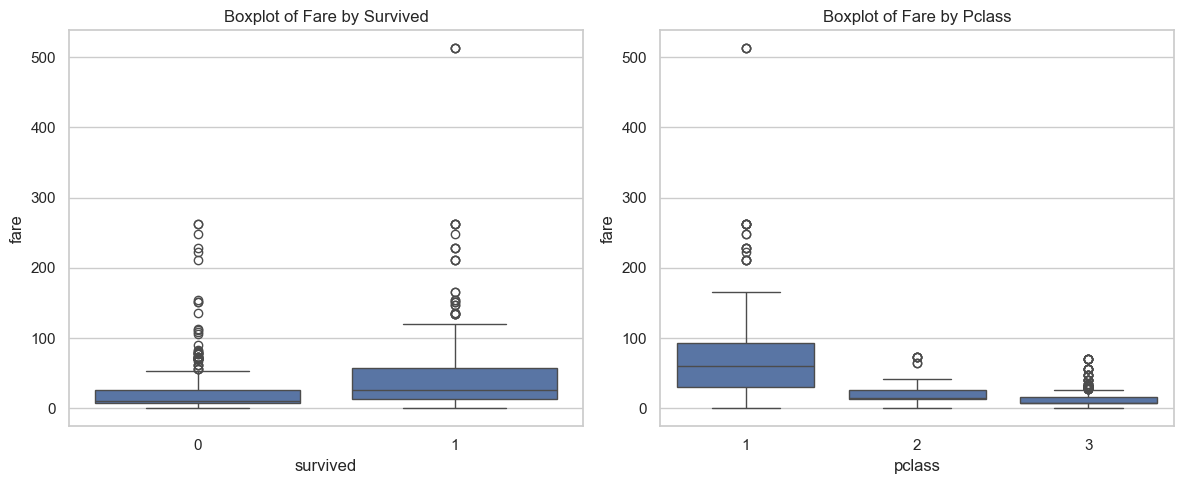

Ellipsis

In [22]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x="survived", y="fare", data=df, ax=axes[0])
axes[0].set_title("Boxplot of Fare by Survived")
sns.boxplot(x="pclass", y="fare", data=df, ax=axes[1])
axes[1].set_title("Boxplot of Fare by Pclass")
plt.tight_layout()
plt.show()
...

## Nhận xét

Boxplot `fare` theo `survived` đã thể hiện một sự thất rất thú vị. Phần lớn những người thiệt mạng trong vụ tai nạn đều sở hữu chiếc vé có giá trị thấp, có thể vị trí ngồi của họ là không thuận tiện để tiếp cận tàu cứu hộ, thoát khỏi tàu nhanh chóng. Dẫu vậy vần tồn tại nhiều du khách bỏ ra số tiền lớn mua vé nhưng vẫn thiệt mạng. 

Bocplot `fare` theo `pclass` là rất hợp lí khi giá vé càng cao thì hạng mức chỗ ngồi càng cao. Phần lớn du khách sở hữu chiếc vé có giá trị thấp đều thuộc hạng 3 và tất nhiên những du khách bỏ ra số tiền lớn thì họ thuộc vé hạng 1.

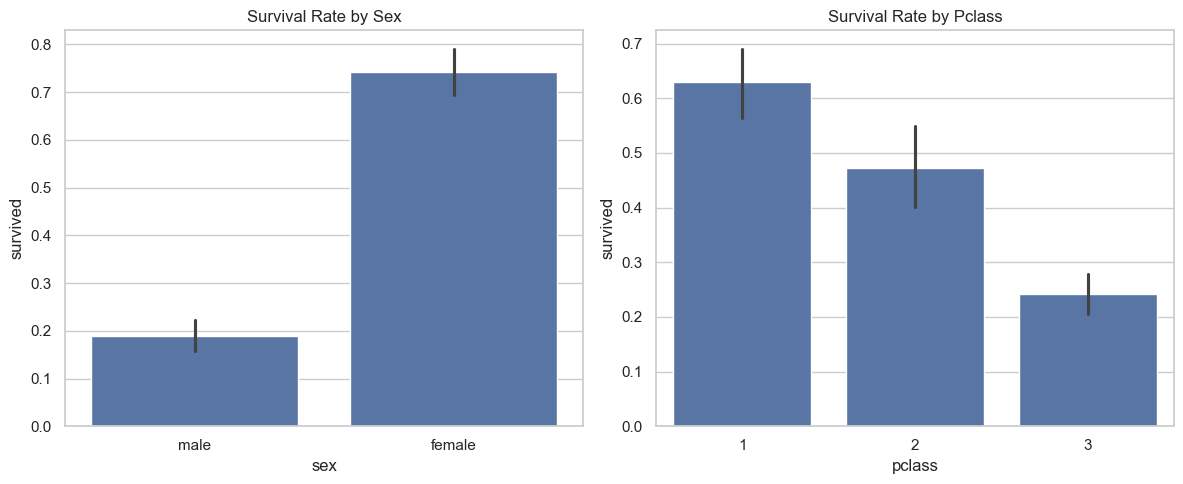

Ellipsis

In [23]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x="sex", y="survived", data=df, ax=axes[0])
axes[0].set_title("Survival Rate by Sex")
sns.barplot(x="pclass", y="survived", data=df, ax=axes[1])
axes[1].set_title("Survival Rate by Pclass")
plt.tight_layout()
plt.show()
...

## Nhận xét

Barplot tỷ lệ sống sót theo `Sex` đã thể hiện một sự thật thú vị. Phần lớn những người may mắn thoát khỏi cuộc tai nạn là phụ nữ, tỷ lệ sống sót của họà hơn 70% cao gấp ba lần so với đàn ông. Thông tin này cần tìm hiểu thêm vì có thể đa số du khách trên tàu là phụ nữ hoặc trong tình huống nguy hiểm những người phụ nữ đã được ưu tiên di chuyển lên tàu cứu hộ để thoát khỏi tàu.

Barplot tỷ lệ sống sót theo `pclass` cũng đã thể hiện thông tin dễ hiểu khi du khách sở hữu hạng mức vé càng cao thì càng được ưu tiên hỗ trợ để rời khỏi tàu nhanh chóng. Tỷ lệ sống sót của hạng mức vé cao nhất lên đến hơn 60%, đây là tỉ lệ rất cao khi ta so sánh với tỷ lệ sống sót của hạng vé thấp nhất, chỉ vỏn vẹn hơn 20%.

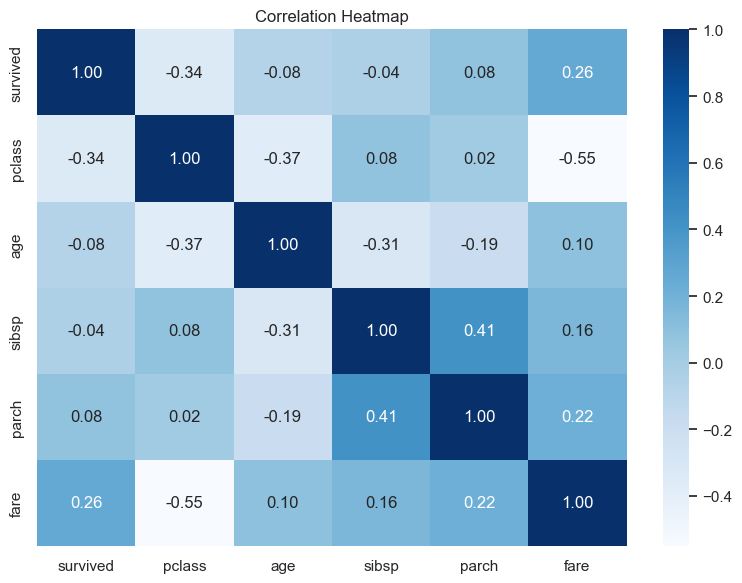

Ellipsis

In [24]:
# TODO 5d: Heatmap correlation
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(data=df.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap="Blues", ax=ax)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
...

## Nhận xét

`fare` và `pclass` có độ tương quan âm lớn nhất vì hạng mức vé càng cao (1 > 2 > 3) thì số tiền bỏ ra là càng lớn

Bên cạnh đó 2 đặc trưng `fare` và `pclass` là 2 đặc trưng có độ tương quan rõ rệt hơn với `survived` khi so sánh với các đặc trưng khác, điều này đã được giải thích ở trên với nhận định ban đầu có thể du khách trả tiền càng nhiều thì càng có hạng vé cao từ đó mà vị trí là rất thuận tiện cho việc nhanh chóng thoát khỏi tàu cũng như là được nhiều nhân viên ưu tiên hỗ trợ.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [25]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=["survived"])
y = df["survived"]

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=15/85, random_state=42, stratify=y_tmp)

print("Train/Val/Test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])
# in tỷ lệ survived từng tập
print("Survival Rates:")
print("Train:", y_train.mean())
print("Val:", y_val.mean())
print("Test:", y_test.mean())

Train/Val/Test: 623 134 134
Survival Rates:
Train: 0.38362760834670945
Val: 0.3880597014925373
Test: 0.3805970149253731


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [26]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)
print("Shapes sau biến đổi:", X_train_t.shape, X_val_t.shape, X_test_t.shape)
print("Tên cột:", list(preprocess.get_feature_names_out()))
print("Có NaN sau tiền xử lý không?", np.isnan(X_train_t.toarray() if hasattr(X_train_t, "toarray") else X_train_t).any())

Shapes sau biến đổi: (623, 8) (134, 8) (134, 8)
Tên cột: ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_male', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']
Có NaN sau tiền xử lý không? False


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Fit học median, mode, IQR/median để scale và danh mục one-hot. Nếu fit trên toàn bộ dữ liệu, các tham số đã chứa thông tin validation/test và làm điểm đánh giá lạc quan giả tạo. Fit chỉ trên train rồi transform validation/test mô phỏng dữ liệu mới, vì vậy tránh leakage.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [27]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print("Tỷ lệ hai lớp của 'survived':")
print(y.value_counts(normalize=True))

...

Tỷ lệ hai lớp của 'survived':
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


Ellipsis

**Trả lời 8:**

1. Biến mục tiêu `survived` đang mất cân bằng nhẹ, tỉ lệ khoảng 60:40, nên vẫn có thể sử dụng Accuracy để đánh giá, nhưng không nên chỉ dùng Accuarcy để đánh giá.
2. Nếu mô hình luôn cho kết quả là `0` thì đã đạt Accuracy = 61%, vì thế ta nên bổ sung thêm các phương pháp đánh giá khác.
3. Đối bài toán Titanic, dự đoán kết quả `survived` dựa trên các đặc trưng cho trước, ta nên ưu tiên metric F1 vì nó cân bằng giữa Precision và Recall, phù hợp hơn Accuracy khi dữ liệu không hoàn toàn cân bằng và cần đánh giá hiệu quả của cả hai vấn đề (i) phản ánh việc bỏ sót nhiều người sống sót và (ii) phản ánh việc dự đoán nhầm quá nhiều người sống sót.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Sau khi chọn đặc trưng, dữ liệu có 891 dòng và 8 cột; sex là tín hiệu mạnh qua tỷ lệ sống sót nữ khoảng 74.2% và nam khoảng 18.9%. Ngoài ra vé hạng 1 có tỷ lệ sống sót khoảng 63.0%, cao hơn nhiều so với hạng 3 khoảng 24.2%; pclass và fare liên hệ với survived.
2. `age` thiếu 177 giá trị (19.87%) và `embarked` thiếu 2 giá trị (0.22%). Đối với biến số `age`, ta điền median để tránh bị ảnh hưởng bởi các outliers, biến phân loại `embarked` thì điền mode.
3. Biến mục tiêu `survived`mat61 cân bằng nhẹ với tỷ lệ khoảng 61.6:38.4, vì vậy không đánh giá bằng Accuracy một mình mà ưu tiên F1 để đảm bảo đánh giá đầy đủ hai tiêu chí (i) phản ánh việc bỏ sót nhiều người sống sót và (ii) phản ánh việc dự đoán nhầm quá nhiều người sống sót.
4. Fare có đuôi phải và outlier có ý nghĩa thực tế nên được giữ lại, sau đó dùng RobustScaler; sex và embarked được one-hot encode.
5. Điều thú vị nhất trong dữ liệu là tỷ lệ sống sót củ a phụ nữ cao bất thường, các đặc trưng `fare` hay `pclass` cũng không có được mức tương quan rõ rệt như `sex`. Ngoài ra khi tạo thêm đặc trưng mới `family_size` và `family_group`, ta càng nhận ra thêm một chi tiết thú vị. Khi bạn tham gia chuyến tàu củng với rất nhiều thành viên trong gia đình (từ 5 trở lên) thì tỷ lệ sống sót rất thấp. Một gia đình có từ 2 đến 4 thành viên là lý tưởng nhất để tỷ lệ sống sót cao hơn trung bình.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

Độ tương quan = 0.017


,Số hành khách,Tỷ lệ sống sót
family_size,,
1,537,0.304
2,161,0.553
3,102,0.578
4,29,0.724
5,15,0.200
6,22,0.136
7,12,0.333
8,6,0.000
11,7,0.000


,Số hành khách,Tỷ lệ sống sót
family_group,,
Một mình (1),537,0.304
Gia đình nhỏ (2-4),292,0.579
Gia đình đông (>=5),62,0.161


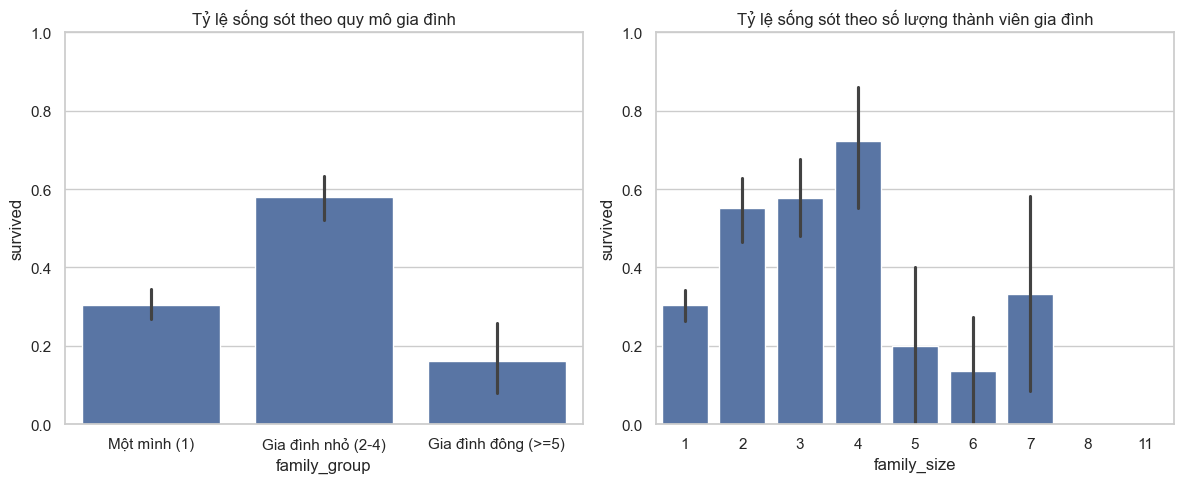

In [28]:
# Bonus Task 1: tạo đặc trưng quy mô gia đình và kiểm tra với survived.
df_bonus = df.copy()
df_bonus["family_size"] = df_bonus["sibsp"] + df_bonus["parch"] + 1
df_bonus["family_group"] = pd.cut(df_bonus["family_size"], bins=[0, 1, 4, np.inf], labels=["Một mình (1)", "Gia đình nhỏ (2-4)", "Gia đình đông (>=5)"])

print(f"Độ tương quan = {df_bonus['family_size'].corr(df_bonus['survived']):.3f}")

family_summary = df_bonus.groupby("family_size")["survived"].agg(["count", "mean"]).rename(columns={"count": "Số hành khách", "mean": "Tỷ lệ sống sót"})
display(family_summary.round(3))

family_group_summary = df_bonus.groupby("family_group")["survived"].agg(["count", "mean"]).rename(columns={"count": "Số hành khách", "mean": "Tỷ lệ sống sót"})
display(family_group_summary.round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df_bonus, x="family_group", y="survived", ax=ax[0])
ax[0].set_title("Tỷ lệ sống sót theo quy mô gia đình")
ax[0].set_ylim(0, 1)

sns.barplot(data=df_bonus, x="family_size", y="survived", ax=ax[1])
ax[1].set_title("Tỷ lệ sống sót theo số lượng thành viên gia đình")
ax[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
